In [69]:
# library load
import pandas as pd
import pyarrow
import numpy as np

from tabulate import tabulate
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score,precision_recall_curve, recall_score, f1_score, roc_curve, average_precision_score, log_loss
from sklearn.ensemble import RandomForestClassifier

import warnings

random_seed = 19

In [24]:
# data load
data = pd.read_csv("/Users/charliepeng/Downloads/420_Final/final_dataset.csv")
data = data.drop('result', axis=1)
data.columns

Index(['game_id', 'season', 'week', 'home_team', 'away_team', 'home_win',
       'home_ewma_rushing_offense', 'home_ewma_passing_offense',
       'home_ewma_rushing_defense', 'home_ewma_passing_defense',
       'away_ewma_rushing_offense', 'away_ewma_passing_offense',
       'away_ewma_rushing_defense', 'away_ewma_passing_defense'],
      dtype='object')

In [25]:
# look at distributions

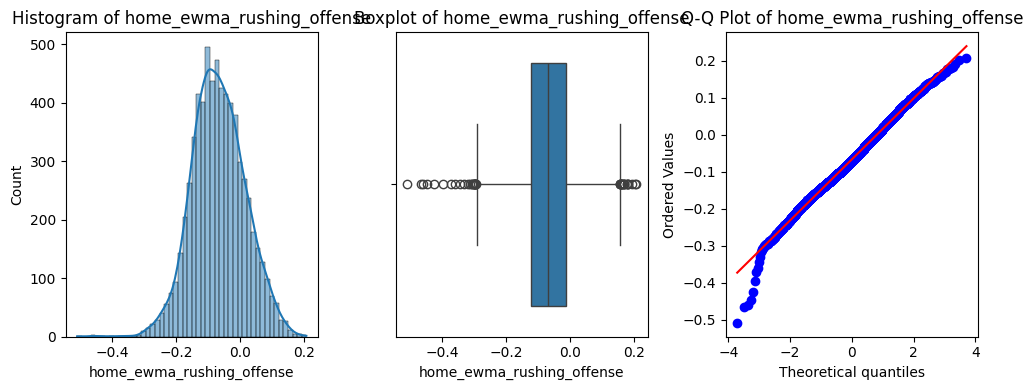

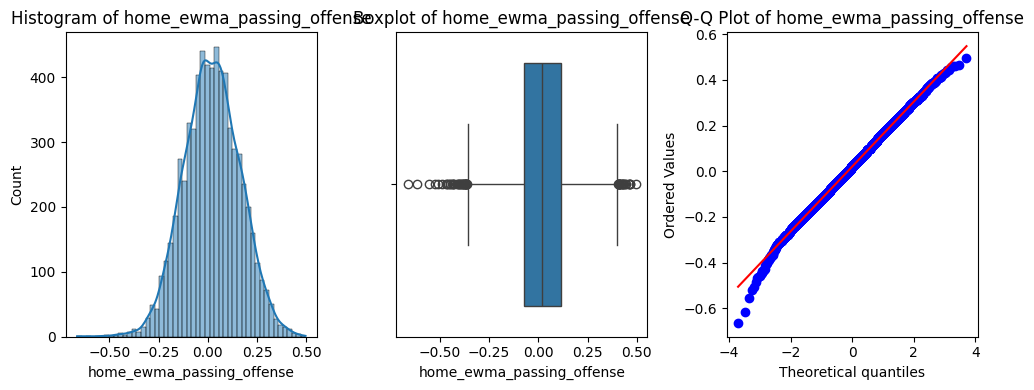

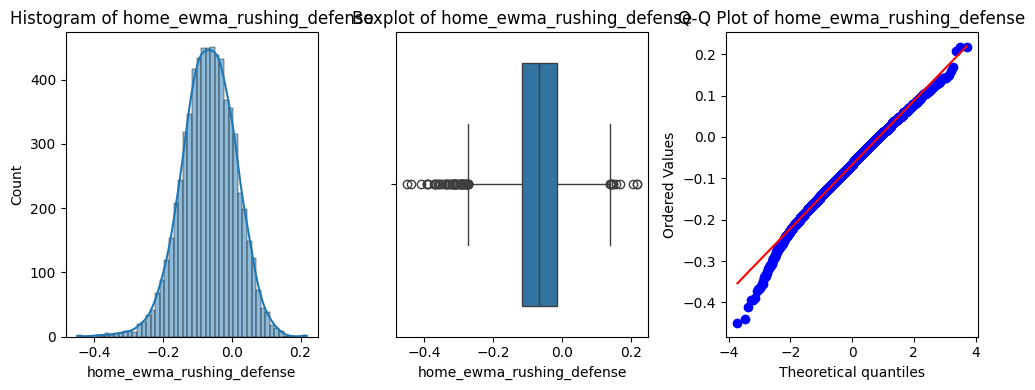

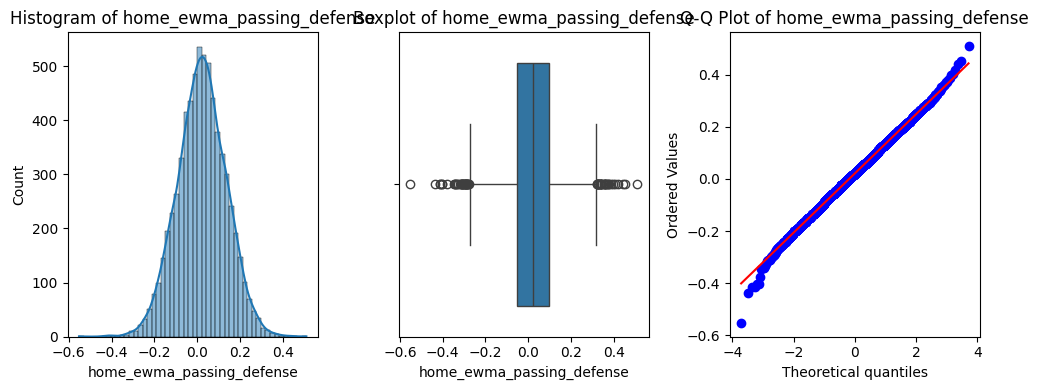

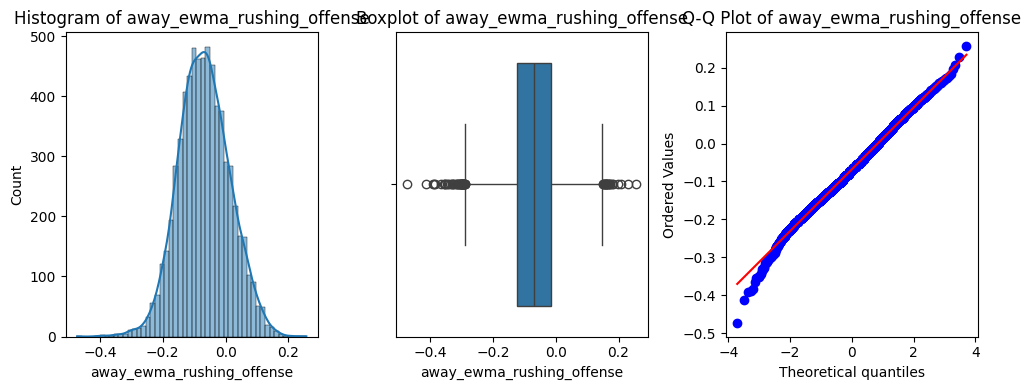

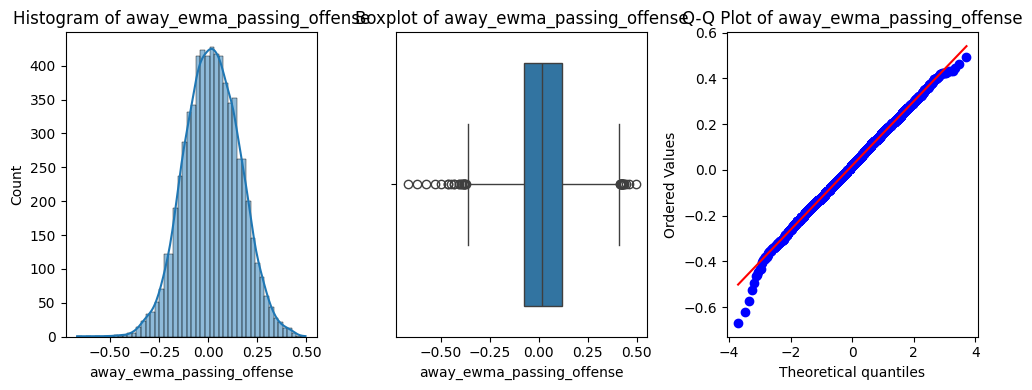

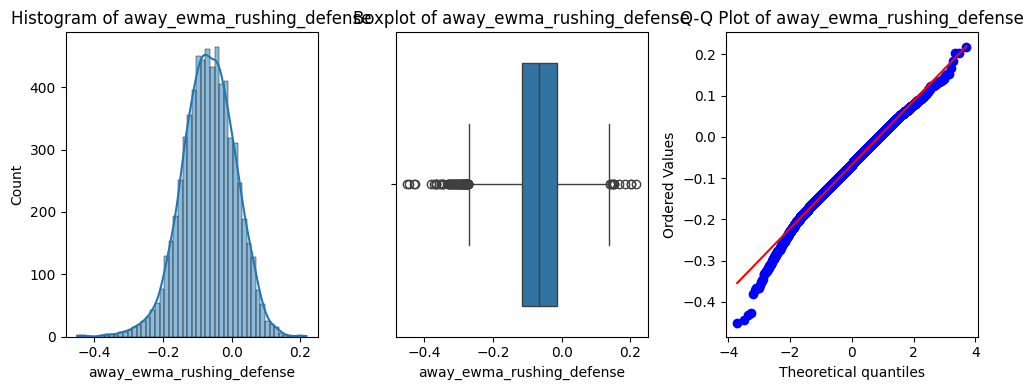

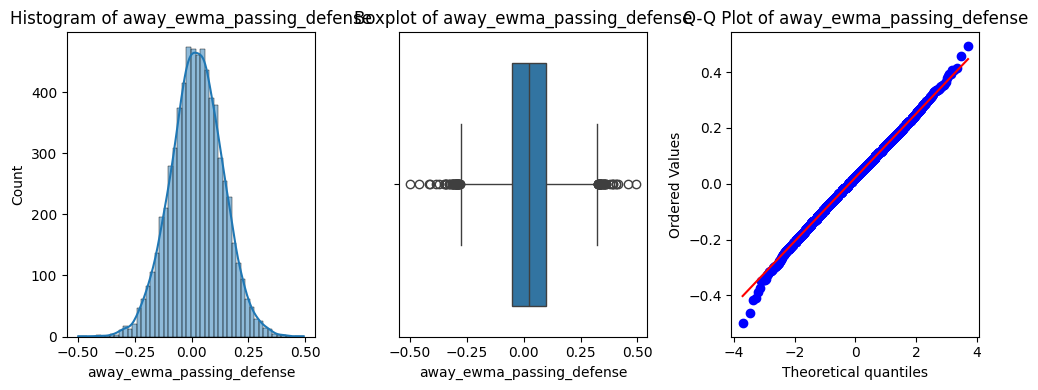

In [26]:
cols = ['home_ewma_rushing_offense', 'home_ewma_passing_offense',
       'home_ewma_rushing_defense', 'home_ewma_passing_defense',
       'away_ewma_rushing_offense', 'away_ewma_passing_offense',
       'away_ewma_rushing_defense', 'away_ewma_passing_defense']

for col in cols:
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    sns.histplot(data[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')

    sns.boxplot(x=data[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    stats.probplot(data[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title(f'Q-Q Plot of {col}')

    plt.tight_layout()
    plt.show()

Most distributions look close to normal with limited outliers. Some are skewed more to the left due to the presence of more extreme values and outliers.

We can plot a correlation heatmap again to look at the relationships between our target variable home_win and our explanatory features.

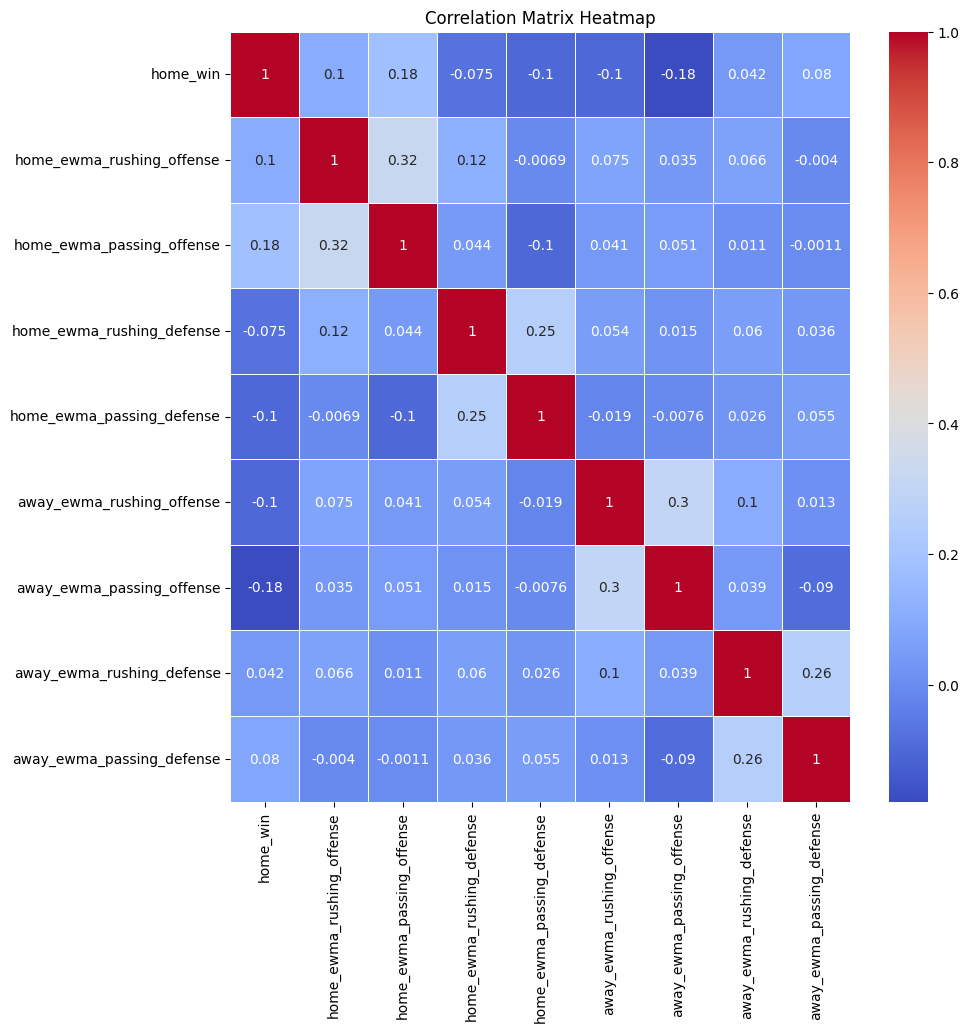

In [27]:
q_cols = ['home_win', 'home_ewma_rushing_offense', 'home_ewma_passing_offense',
       'home_ewma_rushing_defense', 'home_ewma_passing_defense',
       'away_ewma_rushing_offense', 'away_ewma_passing_offense',
       'away_ewma_rushing_defense', 'away_ewma_passing_defense']

corrmat = data[q_cols].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corrmat, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap')

plt.show() 

In [28]:
# Model 1: Logistic Regression

In [29]:
print(f"Total games: {len(data):,}")
print(f"Home win rate: {data['home_win'].astype(int).sum()/len(data):.3f}")

Total games: 6,715
Home win rate: 0.564


In [30]:
features = [
    'home_ewma_rushing_offense',
    'home_ewma_passing_offense',
    'home_ewma_rushing_defense',
    'home_ewma_passing_defense',
    'away_ewma_rushing_offense',
    'away_ewma_passing_offense',
    'away_ewma_rushing_defense',
    'away_ewma_passing_defense',
]
target = 'home_win'

# train on all seasons except 2024, hold out 2024
train = data[data['season'] != 2024]
test  = data[data['season'] == 2024]

scaler = StandardScaler()

X_train = train[features].values
y_train = train[target].values
X_test = test[features].values
y_test = test[target].values

X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(train):,} games | Test (2024): {len(test):,} games")

Train: 6,430 games | Test (2024): 285 games


In [31]:
# using leave one group out cross validation to make sure we don't train on future games to predict past ones 
# - ensures that temporal nature of data is respected

In [32]:
# target variable
y = data['home_win']

# features
X = data.drop(columns=['home_win'])

In [33]:
y = data['home_win']
X = data.drop(columns=['home_win', 'game_id', 'home_team', 'away_team'])

model_data = pd.concat([X, y], axis=1).dropna()

y = model_data['home_win']
X = model_data.drop(columns=['home_win'])

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
warnings.filterwarnings("ignore")

model1 = LogisticRegression(random_state=random_seed)
model1.fit(X_scaled, y_train)

y_train_pred = model1.predict(X_scaled)
print("Training Results: ")
print("precision: ", precision_score(y_train, y_train_pred))
print("recall: ", recall_score(y_train, y_train_pred))
print("f1 score: ", f1_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Training Results: 
precision:  0.6487622606258757
recall:  0.7650784907738915
f1 score:  0.7021357260204727
              precision    recall  f1-score   support

           0       0.60      0.46      0.52      2799
           1       0.65      0.77      0.70      3631

    accuracy                           0.63      6430
   macro avg       0.63      0.61      0.61      6430
weighted avg       0.63      0.63      0.62      6430



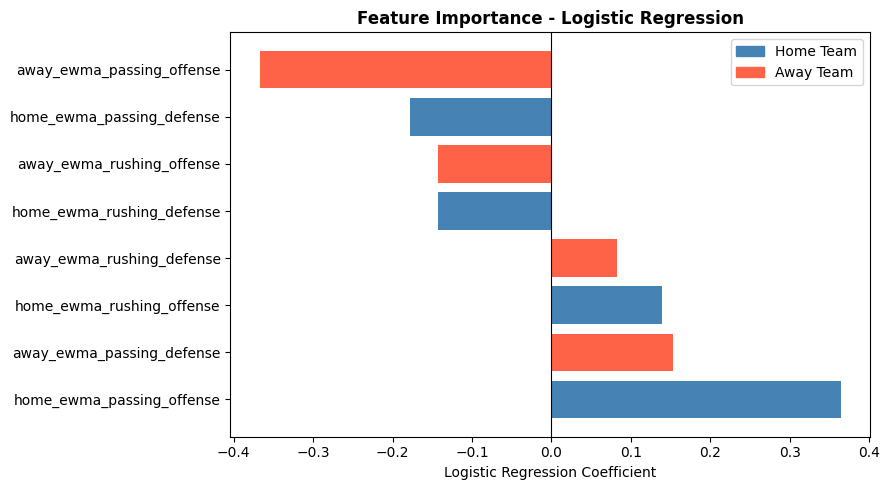

In [35]:
# feature importance
fig, ax = plt.subplots(figsize=(9, 5))

coef_pairs = sorted(zip(features, model1.coef_[0]), key=lambda x: x[1], reverse=True)
feat_names, coef_vals = zip(*coef_pairs)

# clean up labels for display
#labels = [f.replace('ewma_dynamic_', '').replace('_', ' ') for f in feat_names]
colors = ['steelblue' if 'home' in f else 'tomato' for f in feat_names]

ax.barh(feat_names, coef_vals, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Importance - Logistic Regression', fontweight='bold')
ax.set_xlabel('Logistic Regression Coefficient')

ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Home Team'),
    mpatches.Patch(color='tomato', label='Away Team')
])
plt.tight_layout()
plt.show()

In [36]:
groups = train['season'].values
logo = LeaveOneGroupOut()

acc_scores = cross_val_score(model1, X_scaled, y_train, cv=logo, groups=groups, scoring='accuracy')
loss_scores = cross_val_score(model1, X_scaled, y_train, cv=logo, groups=groups, scoring='neg_log_loss')
f1_scores = cross_val_score(model1, X_scaled, y_train, cv=logo, groups=groups, scoring='f1_weighted')

print(f'Cross Validated Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}')
print(f'Cross Validated Negative Log Loss : {np.mean(loss_scores):.4f}')
print(f'Cross Validated F1 Score : {np.mean(f1_scores):.4f}')

Cross Validated Accuracy : 0.6326 ± 0.0277
Cross Validated Negative Log Loss : -0.6380
Cross Validated F1 Score : 0.6232


In [37]:
# Make predictions on the test set
y_test_pred = model1.predict(X_test_scaled)
print("Testing Results: ")
print("precision: ", precision_score(y_test, y_test_pred))
print("recall: ", recall_score(y_test, y_test_pred))
print("f1 score: ", f1_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Testing Results: 
precision:  0.6802325581395349
recall:  0.75
f1 score:  0.7134146341463414
              precision    recall  f1-score   support

           0       0.65      0.57      0.61       129
           1       0.68      0.75      0.71       156

    accuracy                           0.67       285
   macro avg       0.67      0.66      0.66       285
weighted avg       0.67      0.67      0.67       285



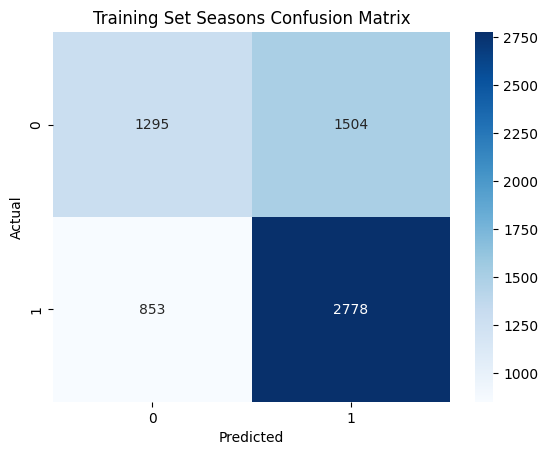

In [38]:
# training set seasons
y_train_preds = model1.predict(X_scaled)

conf_mat=confusion_matrix(y_train, y_train_preds)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Set Seasons Confusion Matrix')
plt.show()

The accuracy is higher than our baseline accuracy of 56.4% from just predicting a home team win every time, but the log loss is quite high too, which means the model makes confident wrong predictions. The confusion matrix shows that the model does not do well predicting home team losses.

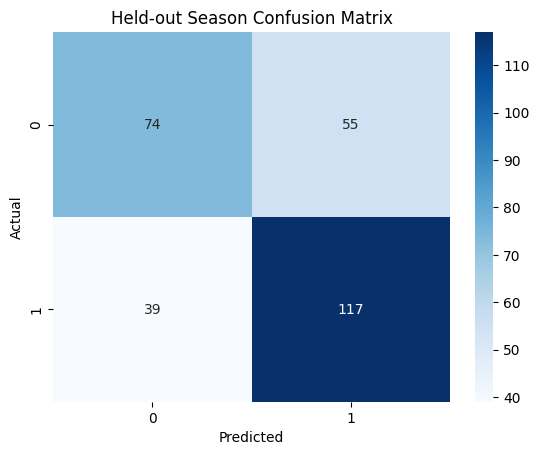

In [39]:
# test on held out season
y_preds = model1.predict(X_test_scaled)

conf_mat=confusion_matrix(y_test, y_preds)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Held-out Season Confusion Matrix')
plt.show()

In [40]:
# try hypertuning
warnings.filterwarnings("ignore")

params = [
    {'solver': ['lbfgs', 'newton-cg', 'sag'], 'penalty': ['l2', None],'C': np.logspace(-4, 4, 20),'max_iter': [500, 1000, 2500, 5000]},
    {'solver': ['liblinear'], 'penalty':  ['l1', 'l2'],'C': np.logspace(-4, 4, 20),'max_iter': [500, 1000, 2500, 5000]},
    {'solver': ['saga'], 'penalty': ['l1', 'l2', 'elasticnet', None],'C': np.logspace(-4, 4, 20),'max_iter': [500, 1000, 2500, 5000],'l1_ratio': [0.25, 0.5, 0.75]}
]
grid_s = GridSearchCV(LogisticRegression(random_state=random_seed),param_grid=params,cv=3,verbose=True,n_jobs=-1,scoring='accuracy')

grid_s.fit(X_scaled, y_train)

best_model = grid_s.best_estimator_

print(f"Best Parameters : {grid_s.best_params_}")
print(f"Best Accuracy   : {grid_s.best_score_:.4f}")

Fitting 3 folds for each of 1600 candidates, totalling 4800 fits
Best Parameters : {'C': np.float64(0.012742749857031334), 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Best Accuracy   : 0.6339


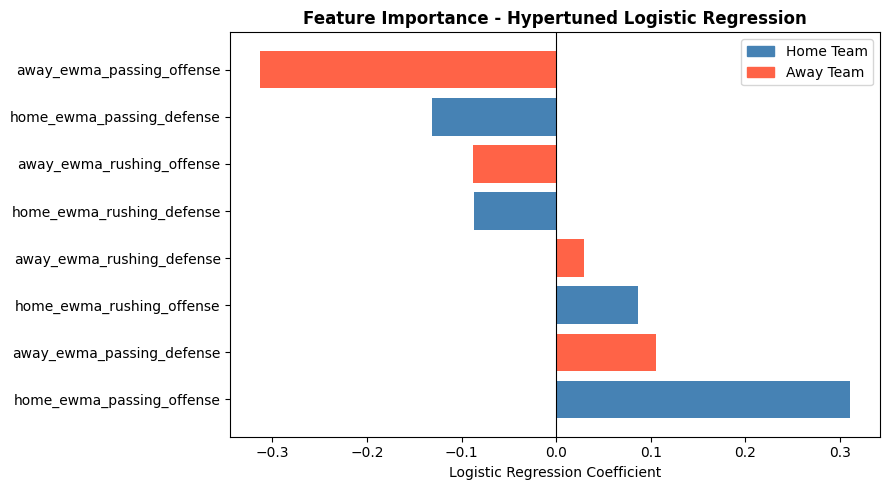

In [41]:
# feature importance
fig, ax = plt.subplots(figsize=(9, 5))

coef_pairs = sorted(zip(features, best_model.coef_[0]), key=lambda x: x[1], reverse=True)
feat_names, coef_vals = zip(*coef_pairs)

# clean up labels for display
#labels = [f.replace('ewma_dynamic_', '').replace('_', ' ') for f in feat_names]
colors = ['steelblue' if 'home' in f else 'tomato' for f in feat_names]

ax.barh(feat_names, coef_vals, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Importance - Hypertuned Logistic Regression', fontweight='bold')
ax.set_xlabel('Logistic Regression Coefficient')

ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Home Team'),
    mpatches.Patch(color='tomato', label='Away Team')
])
plt.tight_layout()
plt.show()

In [42]:
# refit best model and evaluate
acc_scores  = cross_val_score(best_model, X_scaled, y_train, cv=logo, groups=groups, scoring='accuracy')
loss_scores = cross_val_score(best_model, X_scaled, y_train, cv=logo, groups=groups, scoring='neg_log_loss')

print(f"LOGO Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"LOGO Neg Log Loss : {np.mean(loss_scores):.4f}")

warnings.resetwarnings()

LOGO Accuracy : 0.6336 ± 0.0318
LOGO Neg Log Loss : -0.6411


In [43]:
y_train_pred = best_model.predict(X_scaled)
print("Training Results: ")
print("precision: ", precision_score(y_train, y_train_pred))
print("recall: ", recall_score(y_train, y_train_pred))
print("f1 score: ", f1_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Training Results: 
precision:  0.6524988323213452
recall:  0.7694849903607821
f1 score:  0.7061797042840895
              precision    recall  f1-score   support

           0       0.61      0.47      0.53      2799
           1       0.65      0.77      0.71      3631

    accuracy                           0.64      6430
   macro avg       0.63      0.62      0.62      6430
weighted avg       0.63      0.64      0.63      6430



Even with hypertuning, it looks like the best combination does not improve our performance scores. This is possibly due to logistic regression still being a linear model, which means it can only draw straight decision boundaries. The best parameters found (C=0.013, l1) suggest heavy regularization is optimal, meaning the model is actively shrinking coefficients because the features aren't that predictive.

We can attempt a non-linear model to see if we improve the performance.

### Random Forest

In [44]:
# random forest
# Initialize and train the Random Forest classifier
warnings.filterwarnings("ignore")

model2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=random_seed, n_jobs=-1)
model2.fit(X_train, y_train)

y_train_pred = model2.predict(X_train)
print("Training Results: ")
print("precision: ", precision_score(y_train, y_train_pred))
print("recall: ", recall_score(y_train, y_train_pred))
print("f1 score: ", f1_score(y_train, y_train_pred))
print("accuracy: ", accuracy_score(y_train, y_train_pred))

print(" ")

# Make predictions on the test set
y_test_pred = model2.predict(X_test)
print("Validation Results: ")
print("precision: ", precision_score(y_test, y_test_pred))
print("recall: ", recall_score(y_test, y_test_pred))
print("f1 score: ", f1_score(y_test, y_test_pred))
print("accuracy: ", accuracy_score(y_test, y_test_pred))

Training Results: 
precision:  1.0
recall:  1.0
f1 score:  1.0
accuracy:  1.0
 
Validation Results: 
precision:  0.6818181818181818
recall:  0.7692307692307693
f1 score:  0.7228915662650602
accuracy:  0.6771929824561403


In [45]:
acc_scores = cross_val_score(model2, X_train, y_train, cv=logo, groups=groups, scoring='accuracy')
loss_scores = cross_val_score(model2, X_train, y_train, cv=logo, groups=groups, scoring='neg_log_loss')

print(f'Cross Validated Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}')
print(f'Cross Validated Negative Log Loss : {np.mean(loss_scores):.4f}')

#warnings.resetwarnings()

Cross Validated Accuracy : 0.6197 ± 0.0243
Cross Validated Negative Log Loss : -0.6520


In [46]:
%%time
# hypertuning
param_grid = {
    'max_depth': [10, 20, 30],
    'n_estimators': [400, 500],
    'min_samples_leaf':[20, 50, 100],
    'max_features': ['sqrt','log2'],
    'criterion': ['gini']
}

# Initialize a Random Forest Classifier and GridSearchCV
rf = RandomForestClassifier(random_state=random_seed, class_weight='balanced')
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='f1_weighted')

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)


# Extract the best hyperparameters
best_params = grid_search.best_params_
  
# Train the Random Forest classifier with the best hyperparameters
best_model = RandomForestClassifier(**best_params, random_state=random_seed)
best_model.fit(X_train, y_train)

print("Best Parameters: ")
print(best_params)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: 
{'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 500}
CPU times: user 5.77 s, sys: 216 ms, total: 5.99 s
Wall time: 33.8 s


In [47]:
# training set results
y_train_tuned = best_model.predict(X_train)
print("training set precision: ", precision_score(y_train, y_train_tuned))
print("training set recall: ", recall_score(y_train, y_train_tuned))
print("training f1 score: ", f1_score(y_train, y_train_tuned))
print(classification_report(y_train, y_train_tuned))

training set precision:  0.7144840351689032
training set recall:  0.8504544202698981
training f1 score:  0.7765623035332578
              precision    recall  f1-score   support

           0       0.74      0.56      0.64      2799
           1       0.71      0.85      0.78      3631

    accuracy                           0.72      6430
   macro avg       0.73      0.70      0.71      6430
weighted avg       0.73      0.72      0.72      6430



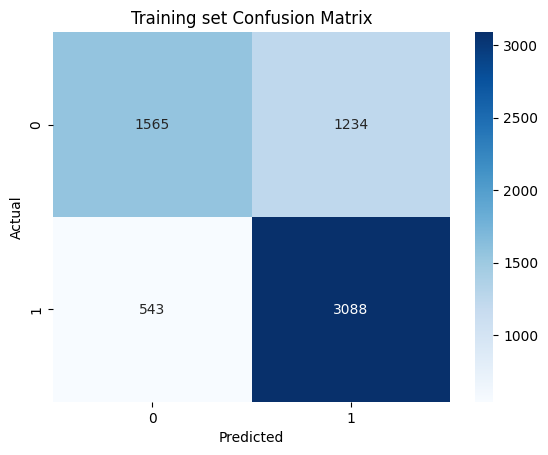

In [48]:
# confusion matrix training set
conf_mat=confusion_matrix(y_train, y_train_tuned)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training set Confusion Matrix')
plt.show()

In [49]:
# decent improvement

In [50]:
# test set
y_pred_tuned = best_model.predict(X_test)

print("Test set precision: ", precision_score(y_test, y_pred_tuned))
print("Test set recall: ", recall_score(y_test, y_pred_tuned))
print("Test set f1 score: ", f1_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Test set precision:  0.6647058823529411
Test set recall:  0.7243589743589743
Test set f1 score:  0.6932515337423313
              precision    recall  f1-score   support

           0       0.63      0.56      0.59       129
           1       0.66      0.72      0.69       156

    accuracy                           0.65       285
   macro avg       0.65      0.64      0.64       285
weighted avg       0.65      0.65      0.65       285



# Model 3: Decision Tree Classifier

In [ ]:
# decision tree
# Initialize and train the Decision Tree classifier
warnings.filterwarnings("ignore")

model3 = DecisionTreeClassifier(class_weight='balanced', random_state=random_seed)
model3.fit(X_train, y_train)

y_train_pred = model3.predict(X_train)
print("Training Results: ")
print("precision: ", precision_score(y_train, y_train_pred))
print("recall: ", recall_score(y_train, y_train_pred))
print("f1 score: ", f1_score(y_train, y_train_pred))
print("accuracy: ", accuracy_score(y_train, y_train_pred))

print(" ")

# Make predictions on test set
y_test_pred = model3.predict(X_test)
print("Validation Results: ")
print("precision: ", precision_score(y_test, y_test_pred))
print("recall: ", recall_score(y_test, y_test_pred))
print("f1 score: ", f1_score(y_test, y_test_pred))
print("accuracy: ", accuracy_score(y_test, y_test_pred))

Training Results: 
precision:  1.0
recall:  1.0
f1 score:  1.0
accuracy:  1.0
 
Validation Results: 
precision:  0.5806451612903226
recall:  0.5769230769230769
f1 score:  0.5787781350482315
accuracy:  0.5403508771929825


In [53]:
acc_scores = cross_val_score(model3, X_train, y_train, cv=logo, groups=groups, scoring='accuracy')
loss_scores = cross_val_score(model3, X_train, y_train, cv=logo, groups=groups, scoring='neg_log_loss')

print(f'Cross Validated Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}')
print(f'Cross Validated Negative Log Loss : {np.mean(loss_scores):.4f}')

Cross Validated Accuracy : 0.5446 ± 0.0309
Cross Validated Negative Log Loss : -16.4144


In [54]:
%%time
# hypertuning
param_grid = {
    'max_depth': [5, 10, 20, 30],
    'min_samples_leaf': [10, 20, 50],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize a Decision Tree Classifier and GridSearchCV
dt = DecisionTreeClassifier(random_state=random_seed, class_weight='balanced')
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='f1_weighted')

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Extract the best hyperparameters
best_params = grid_search.best_params_

# Train the Decision Tree classifier with the best hyperparameters
best_model = DecisionTreeClassifier(**best_params, random_state=random_seed, class_weight='balanced')
best_model.fit(X_train, y_train)

print("Best Parameters: ")
print(best_params)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: 
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
CPU times: user 153 ms, sys: 60.2 ms, total: 213 ms
Wall time: 933 ms


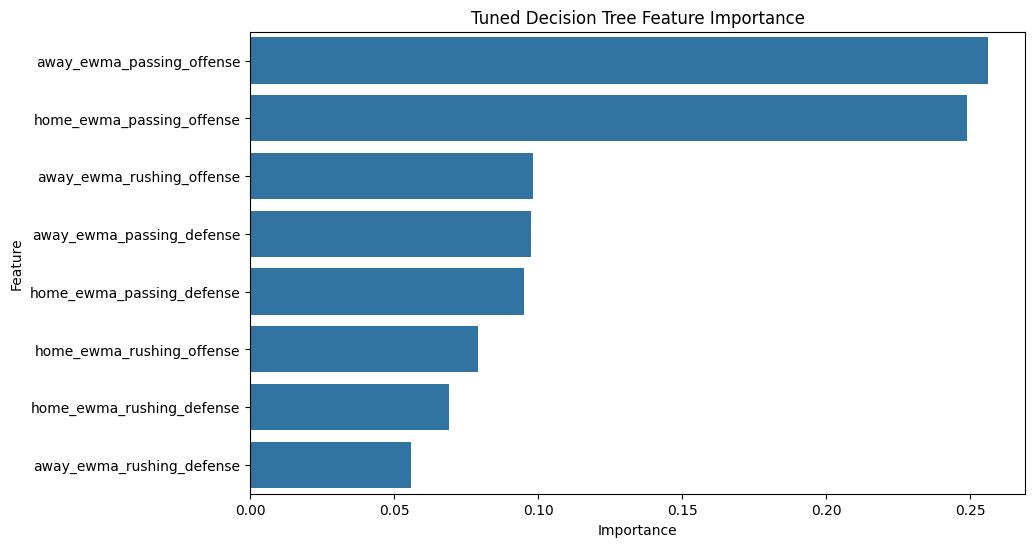

In [71]:
# tuned decision tree feature importance
feature_importance = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Tuned Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# top 5 most important decision tree features
feature_importance = pd.Series(best_tree_model.feature_importances_, index=features).sort_values(ascending=False)
print(feature_importance.head(5))

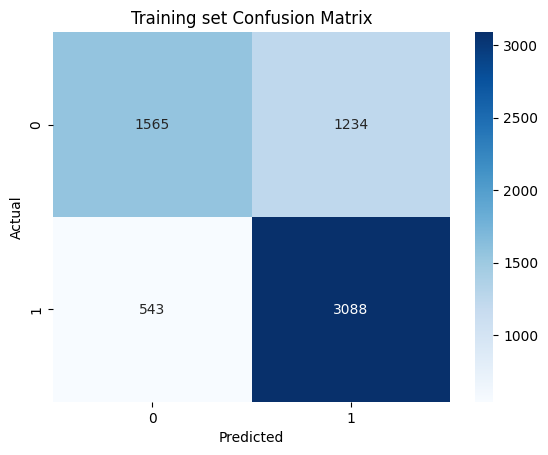

In [55]:
# confusion matrix training set
conf_mat=confusion_matrix(y_train, y_train_tuned)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training set Confusion Matrix')
plt.show()

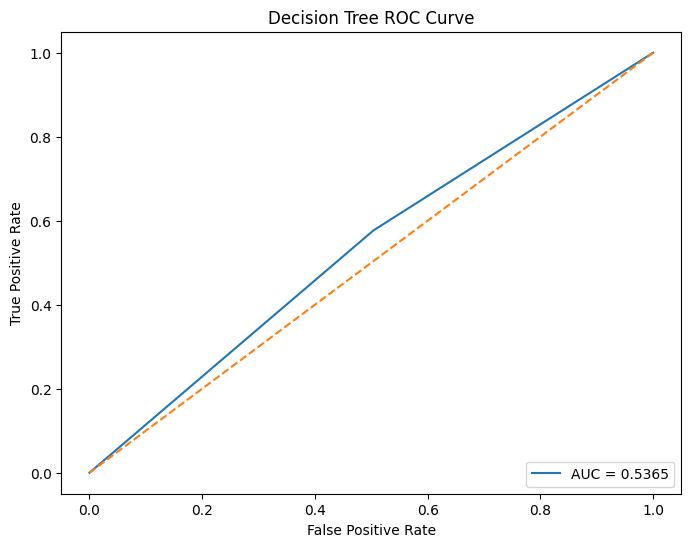

In [66]:
# decision tree roc curve
from sklearn.metrics import roc_curve, auc

y_prob = model3.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [73]:
# decision tree log loss
y_prob_tree = best_model.predict_proba(X_test)
print("Decision Tree Test Log Loss: ", log_loss(y_test, y_prob_tree))

Decision Tree Test Log Loss:  0.6259214041239575


In [56]:
# test set
y_pred_tuned = best_model.predict(X_test)

print("Test set precision: ", precision_score(y_test, y_pred_tuned))
print("Test set recall: ", recall_score(y_test, y_pred_tuned))
print("Test set f1 score: ", f1_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Test set precision:  0.7272727272727273
Test set recall:  0.6153846153846154
Test set f1 score:  0.6666666666666666
              precision    recall  f1-score   support

           0       0.61      0.72      0.66       129
           1       0.73      0.62      0.67       156

    accuracy                           0.66       285
   macro avg       0.67      0.67      0.66       285
weighted avg       0.67      0.66      0.66       285



# Model 4: Gradient Boosting

In [58]:
# Initialize and train the Gradient Boosting classifier
warnings.filterwarnings("ignore")

model4 = GradientBoostingClassifier(random_state=random_seed)
model4.fit(X_train, y_train)

y_train_pred = model4.predict(X_train)
print("Training Results: ")
print("precision: ", precision_score(y_train, y_train_pred))
print("recall: ", recall_score(y_train, y_train_pred))
print("f1 score: ", f1_score(y_train, y_train_pred))
print("accuracy: ", accuracy_score(y_train, y_train_pred))

print(" ")

# Make predictions test set
y_test_pred = model4.predict(X_test)
print("Validation Results: ")
print("precision: ", precision_score(y_test, y_test_pred))
print("recall: ", recall_score(y_test, y_test_pred))
print("f1 score: ", f1_score(y_test, y_test_pred))
print("accuracy: ", accuracy_score(y_test, y_test_pred))

Training Results: 
precision:  0.6928856539093684
recall:  0.8127237675571468
f1 score:  0.7480354879594423
accuracy:  0.6908242612752722
 
Validation Results: 
precision:  0.6705202312138728
recall:  0.7435897435897436
f1 score:  0.7051671732522796
accuracy:  0.6596491228070176


In [59]:
acc_scores = cross_val_score(model4, X_train, y_train, cv=logo, groups=groups, scoring='accuracy')
loss_scores = cross_val_score(model4, X_train, y_train, cv=logo, groups=groups, scoring='neg_log_loss')

print(f'Cross Validated Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}')
print(f'Cross Validated Negative Log Loss : {np.mean(loss_scores):.4f}')

Cross Validated Accuracy : 0.6250 ± 0.0293
Cross Validated Negative Log Loss : -0.6466


In [60]:
%%time
# hypertuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_leaf': [10, 20, 50]
}

# Initialize a Gradient Boosting Classifier and GridSearchCV
gb = GradientBoostingClassifier(random_state=random_seed)
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='f1_weighted')

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Extract the best hyperparameters
best_params = grid_search.best_params_

# Train the Gradient Boosting classifier with the best hyperparameters
best_model = GradientBoostingClassifier(**best_params, random_state=random_seed)
best_model.fit(X_train, y_train)

print("Best Parameters: ")
print(best_params)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: 
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
CPU times: user 2.78 s, sys: 164 ms, total: 2.94 s
Wall time: 36 s


In [61]:
# training set results
y_train_tuned = best_model.predict(X_train)
print("training set precision: ", precision_score(y_train, y_train_tuned))
print("training set recall: ", recall_score(y_train, y_train_tuned))
print("training f1 score: ", f1_score(y_train, y_train_tuned))
print(classification_report(y_train, y_train_tuned))

training set precision:  0.6875293014533521
training set recall:  0.8077664555218947
training f1 score:  0.7428137267316702
              precision    recall  f1-score   support

           0       0.68      0.52      0.59      2799
           1       0.69      0.81      0.74      3631

    accuracy                           0.68      6430
   macro avg       0.68      0.67      0.67      6430
weighted avg       0.68      0.68      0.68      6430



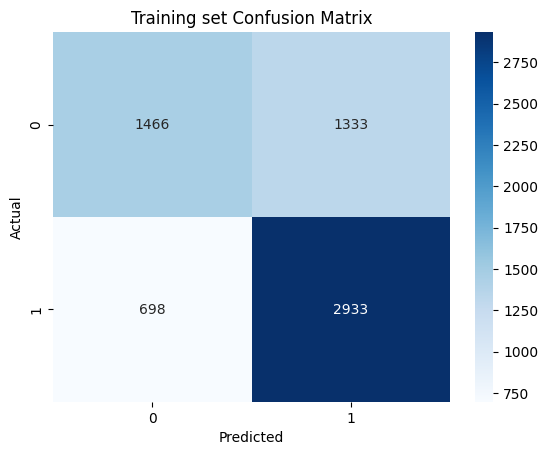

In [62]:
# confusion matrix training set
conf_mat=confusion_matrix(y_train, y_train_tuned)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training set Confusion Matrix')
plt.show()

In [63]:
# test set
y_pred_tuned = best_model.predict(X_test)

print("Test set precision: ", precision_score(y_test, y_pred_tuned))
print("Test set recall: ", recall_score(y_test, y_pred_tuned))
print("Test set f1 score: ", f1_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Test set precision:  0.6647727272727273
Test set recall:  0.75
Test set f1 score:  0.7048192771084337
              precision    recall  f1-score   support

           0       0.64      0.54      0.59       129
           1       0.66      0.75      0.70       156

    accuracy                           0.66       285
   macro avg       0.65      0.65      0.65       285
weighted avg       0.65      0.66      0.65       285

